<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 4
Qn: Desgin and implement a cnn model(with 4+ layers of convolutions) to classify multi category image datasets. use the minst, fashion minst, cifar-10 datasets. set the number of epochs as 5, 10 and 20. make the necessary changes whenever required. record the accuracy corresponding to the number of epochs. record the time required to run the program, using cpu as well as using GPU in colab

In [ ]:
#using fashion mnist dataset
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

#load fashion mnist dataset
(X_train_fashion_mnist, y_train_fashion_mnist), (X_test_fashion_mnist, y_test_fashion_mnist) = fashion_mnist.load_data()

#fashion_mnist shape
print('X_train_fashion_mnist.shape', X_train_fashion_mnist.shape)
print('X_test_fashion_mnist.shape', X_test_fashion_mnist.shape)
print('y_train_fashion_mnist.shape', y_train_fashion_mnist.shape)
print('y_test_fashion_mnist.shape', y_test_fashion_mnist.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train_fashion_mnist.shape (60000, 28, 28)
X_test_fashion_mnist.shape (10000, 28, 28)
y_train_fashion_mnist.shape (60000,)
y_test_fashion_mnist.shape (10000,)


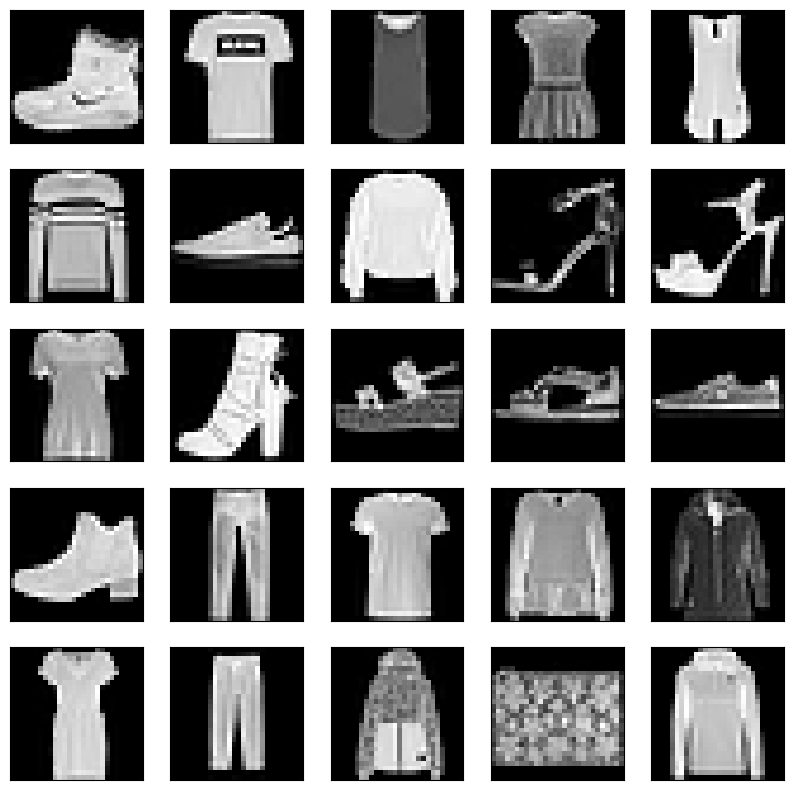

In [ ]:
# display sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train_fashion_mnist[i], cmap='gray')

plt.show()

In [ ]:

#reshape
X_train_fashion_mnist = X_train_fashion_mnist.reshape(-1, 28, 28, 1)
X_test_fashion_mnist = X_test_fashion_mnist.reshape(-1, 28, 28, 1)

#type
X_train_fashion_mnist = X_train_fashion_mnist.astype('float32')/255
X_test_fashion_mnist = X_test_fashion_mnist.astype('float32')/255

#normalize

y_train_fashion_mnist_one_hot = tf.keras.utils.to_categorical(y_train_fashion_mnist)
y_test_fashion_mnist_one_hot = tf.keras.utils.to_categorical(y_test_fashion_mnist)

#print shape
print('X_train_fashion_mnist.shape', X_train_fashion_mnist.shape)
print('X_test_fashion_mnist.shape', X_test_fashion_mnist.shape)

X_train_fashion_mnist.shape (60000, 28, 28, 1)
X_test_fashion_mnist.shape (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation

model = Sequential()
model.add(Conv2D(256, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(Conv2D(32, (3, 3), activation='relu'))


model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 1, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,618 (1.50 MB)

 Trainable params: 392,618 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile the model

print('compiling the model')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print('model compilied')

compiling the model
model compilied


In [ ]:
#train the model
history_X_train_fashion_mnist = model.fit(
     X_train_fashion_mnist, y_train_fashion_mnist_one_hot,
     epochs=10,
     batch_size=128,
     validation_data = (X_test_fashion_mnist, y_test_fashion_mnist_one_hot)
     )

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7709 - loss: 0.6212 - val_accuracy: 0.8454 - val_loss: 0.4345
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8682 - loss: 0.3664 - val_accuracy: 0.8715 - val_loss: 0.3531
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8849 - loss: 0.3148 - val_accuracy: 0.8838 - val_loss: 0.3179
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8985 - loss: 0.2776 - val_accuracy: 0.8895 - val_loss: 0.2971
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9080 - loss: 0.2509 - val_accuracy: 0.8938 - val_loss: 0.2984
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9148 - loss: 0.2317 - val_accuracy: 0.8931 - val_loss: 0.2895
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9218 - loss: 0.2113 - val_accuracy: 0.8929 - val_loss: 0.2815
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9269 - loss: 0.1966 - val_acc

In [ ]:
#evaluate and record accuracy

test_loss, test_acc = model.evaluate(X_test_fashion_mnist, y_test_fashion_mnist_one_hot)
print('Test accuracy:', test_acc)
print('Test Loss:',test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9063 - loss: 0.2691
Test accuracy: 0.9063000082969666
Test Loss: 0.2690882682800293


In [ ]:
#prediction and visual

predictions = model.predict(X_test_fashion_mnist)
print(np.argmax(np.round(predictions[1])))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
2


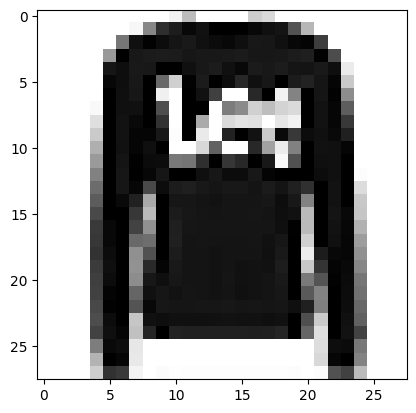

In [ ]:
#Plot the prediction

plt.imshow(X_test_fashion_mnist[1].reshape(28, 28), cmap= plt.cm.binary)
plt.show()



1.   CNN model (4 conv layers)
2.   Dataset (minst fashoin)
3.   Number of Epoches (5,10,20)
4.   Record accuracy
5.   Record time using CPU and GPU


